<a href="https://colab.research.google.com/github/mjss26/EMSC2010-W10-L1-MSS/blob/main/EMSC2010_W10_L1_NB2_MSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB2

In this notebook we'll seperate the long-term and short-term trends in the Keeling curve.

We'll load the Keeling curve datafile directly from the internet and then prepare the data for analysis.



First, import the libraries we'll need.

In [ ]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

Now we will define the address where the data file is stored and load it using ```Pandas```. We then have to do a bit of work to make the file usable for our purposes.

In [ ]:
data_file = 'https://raw.githubusercontent.com/sio-co2o2/keelingcurve_notebooks/main/preliminary_data/mlo/mlo_full_record_now_span.csv' #address of the data file
df = pd.read_csv(data_file,skipinitialspace=True,comment='"') #read in the file
df.head() #show the header information

,date,co2,date_seas_adj,co2_seas_adj,date_fit,co2_fit,date_seas_adj_fit,co2_seas_adj_fit,date_filled,co2_filled,date_seas_adj_filled,co2_seas_adj_filled
0,1958.041096,NaN,1958.041096,NaN,1958.041096,NaN,1958.041096,NaN,1958.041096,NaN,1958.041096,NaN
1,1958.126027,NaN,1958.126027,NaN,1958.126027,NaN,1958.126027,NaN,1958.126027,NaN,1958.126027,NaN
2,1958.202740,315.71,1958.202740,314.43,1958.202740,316.20,1958.202740,314.91,1958.202740,315.71,1958.202740,314.43
3,1958.287671,317.45,1958.287671,315.15,1958.287671,317.30,1958.287671,314.99,1958.287671,317.45,1958.287671,315.15
4,1958.369863,317.51,1958.369863,314.68,1958.369863,317.89,1958.369863,315.06,1958.369863,317.51,1958.369863,314.68


The dataframe contains several variables, but we are only interested in ```date``` and ```co2```.

We can make a new dataframe, called ```df_co2``` with just the variables we want.

Some of the rows contain a ```NaN``` (stands for *not a number*) if there is a missing value. We need to make sure these rows are removed.

Once that's done, we'll convert the data into ```numpy``` arrays.

In [ ]:
df_co2 = df[['date', 'co2']].copy() #new dateframe with the variables we need
df_co2 = df_co2.dropna() #remove rows with missing values
date_co2 = df_co2['date'].to_numpy() #convert dates into numpy array
co2 = df_co2['co2'].to_numpy() #convert co2 into numpy array

Now we can plot the data and we should see the Keeling curve.

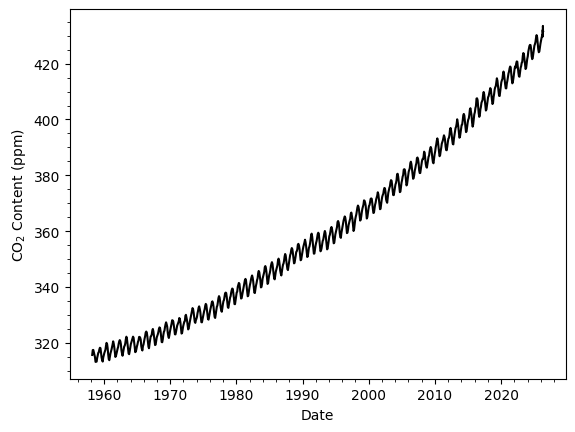

In [ ]:
plt.plot(date_co2,co2,'k') #plot the data
plt.xlabel('Date') #label the x-axis
plt.ylabel('CO$_2$ Content (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

To represent the long term increasing trend we'll try fitting a polynomial to the data. We'll do this with a simple ```numpy``` function called ```polyfit``` rather than a more complex Bayesian model.

We will need to decided what order polynomial provides a good approximation to the long term trend. We'll do this by eye, rather than using a model selection statistic.

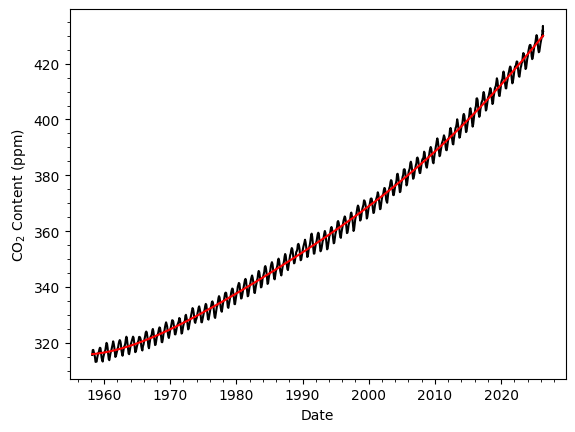

In [ ]:
order = 5 #set the polynomial order
pp = np.polyfit(date_co2,co2,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,date_co2) #find the value of the polynomial at each time point.

plt.plot(date_co2,co2,'k') #plot the data
plt.plot(date_co2,trend,'r') #plot the trend
plt.xlabel('Date') #label the x-axis
plt.ylabel('CO$_2$ Content (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

Next we'll calculate the *residuals*, which are the differences between the data and the fitted polynomial trend. We can compare both the trend and the residuals in a plot.

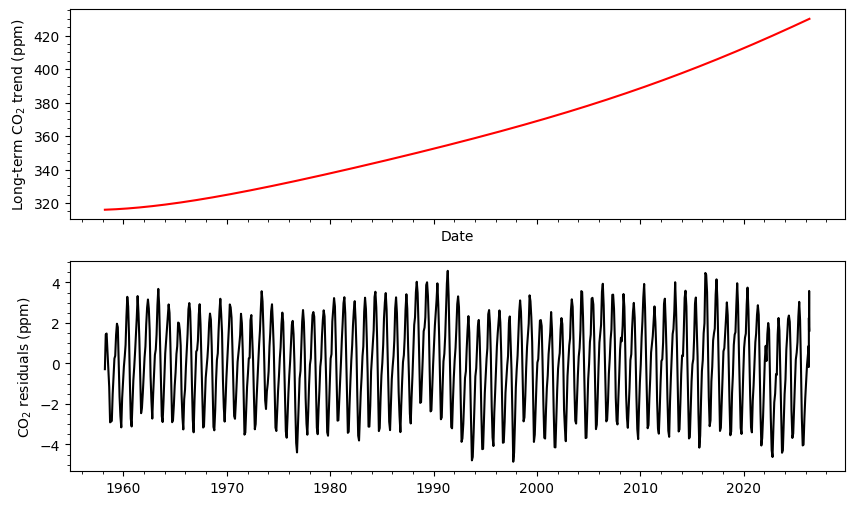

In [ ]:
residuals = co2-trend #find the residuals
fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis

axes[0].plot(date_co2,trend,'r') #plot the polynomial trend
axes[1].plot(date_co2,residuals,'k') #plot the residuals

axes[0].set_xlabel('Date') #label the x-axis
axes[0].set_ylabel('Long-term CO$_2$ trend (ppm)') #label the trend y-axis
axes[1].set_ylabel('CO$_2$ residuals (ppm)') #label the residual y-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks

As we discussed it seems that the annual cycle has some extra structure (remember the shoulder on the peak).

We can take the difference between neighbouring CO$_2$ values to help reveal this pattern. Taking the difference places a stronger emphasis on short-term change in the signal.

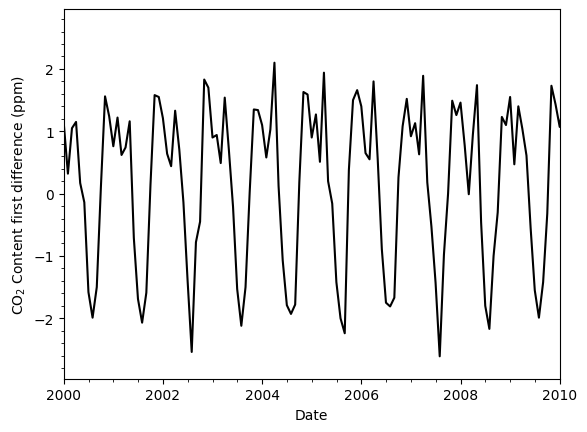

In [ ]:
co2_diff = np.diff(co2) #difference between neighboring points
date_diff = (date_co2[:-1] + date_co2[1:])/2 #find the mid-point in time between points (needed for plotting)
plt.plot(date_diff,co2_diff,'k') #plot the differences
plt.xlim([2000,2010]) #zoom in to see the details

plt.xlabel('Date') #label the x-axis
plt.ylabel('CO$_2$ Content first difference (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks

Above shows Northern hemisphere has spring arriving at different times and so photosythesis begins at large scales at different points of season depending on where large vegetation masses are -> reason for little sholder each year


This approach has revealed extra strcuture in the annual cycle. It looks like something is also happening on a 6 monthly time scale. What do you think this could be?

Importantly, taking the first difference is very sensitive to noise. If we have a noisy signal, we may not be able to see any structure in the first difference.

To demonstrate this, we'll add some random numbers to the data to represent noise. You'll see that the noise hides the true signal in the first difference representation.

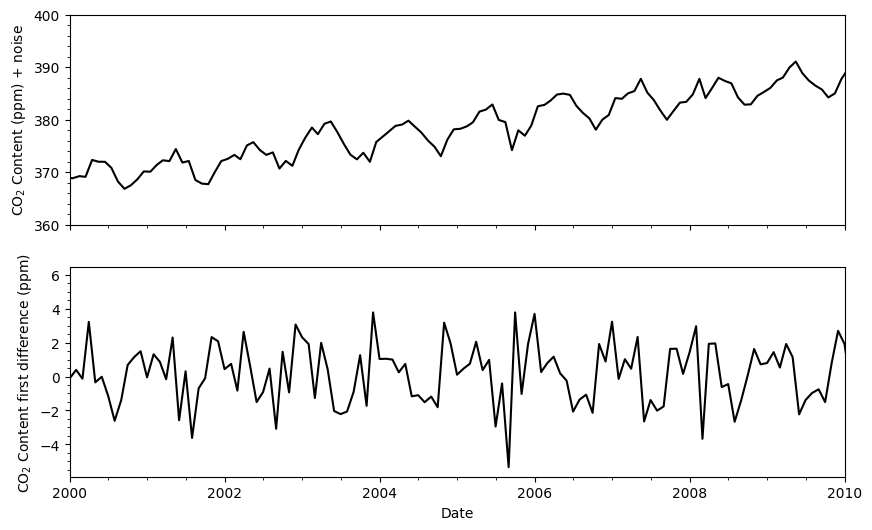

In [ ]:
noisy_co2 = co2 + np.random.normal(0,1,len(co2)) #add some random numbers to act as noise

fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis
axes[0].plot(date_co2,noisy_co2,'k') #plot the noisy data
axes[1].plot(date_diff,np.diff(noisy_co2),'k') #plot the differences
axes[0].set_xlim([2000,2010]) #limit the x-axis
axes[0].set_ylim([360,400]) #limit the y-axis

axes[0].set_ylabel('CO$_2$ Content (ppm) + noise') #label the y-axis
axes[1].set_ylabel('CO$_2$ Content first difference (ppm)') #label the residual y-axis
axes[1].set_xlabel('Date') #label the x-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks